# Turn-Taking Fusion Experiments

### Note that Early Fusion will only work for unimodal data -- or data collected at the same Hz!
#### Also please note you will have to configure a lot of the paths yourself
Thin driver for dyadic-fusion experiments on the turn-taking corpus. All heavy lifting (dataset classes, model classes, training helpers, τ-sweep) lives in `fusion_lib.py`. This notebook just:

1. Declares a modality registry (currently set up for CPC and OpenFace).
2. Declares a dict of experiments — each experiment is `{streams, fusion}` where `streams = [{modality, role}, ...]` and `fusion ∈ {'unimodal', 'early', 'neural_concat'}`.
3. Runs each experiment, collects results, and generates a τ-sweep curve.



## Section 0 — Setup

In [15]:
import os, sys, json
from pathlib import Path
import pandas as pd

# Ensure fusion_lib is importable (same dir as this notebook).
THIS_DIR = Path(os.getcwd())
if str(THIS_DIR) not in sys.path:
    sys.path.insert(0, str(THIS_DIR))

import fusion_lib as fl
import torch
import numpy as np
from tqdm import tqdm

print('torch:', torch.__version__, ' device-available:',
      'cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))

torch: 2.6.0  device-available: mps


In [16]:
# -----------------------------------------------------------------------------
# Paths
# -----------------------------------------------------------------------------
PROJ = THIS_DIR.parents[0]     # .../turn_taking_analysis

# First pass: POC manifest. Swap to 'manifests/manifest.csv' for full-dataset
# runs (requires `build_labeled_windows_from_manifest.py` rerun to extend the
# label files beyond the POC 46 file_ids).

#MANIFEST_PATH = PROJ / 'manifests' / 'manifest_test.csv'
MANIFEST_PATH = '/Users/kaitlinzareno/Desktop/csci535/csci535-project/turn_taking_analysis/manifests/manifest_cpc_available.csv' #local path

#LABELS_DIR = PROJ / 'model_input' / 'labels'
LABELS_DIR = '/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/labels_tau/'
TRAIN_TAU_MS = 400               # canonical training τ per spec §11.5
TRAIN_LABELS_PATH = LABELS_DIR + f'labels_tau_{TRAIN_TAU_MS:04d}.json'

# Dry-run / small-subset mode. Set to None to use all available samples.
# For smoke tests, try MAX_SAMPLES_PER_SPLIT = 200 to verify plumbing end-
# to-end in ~30 s before committing to a full run. Truncation is preceded
# by a seed-deterministic shuffle per split so the subset is representative.
MAX_SAMPLES_PER_SPLIT = None

# Model / training hyperparameters. Defaults match the CSCI-535 practicum
# (multimodal_fusion_practicum.ipynb): GRU_UNITS=64, EPOCHS=30, BATCH_SIZE=32,
# LR=1e-3, patience=4, dropout=0.3, num_layers=3 (EarlyFusion only).
HIDDEN_SIZE       = 64
DROPOUT           = 0.3
NUM_LAYERS_EARLY  = 3            # GRU stack depth for EarlyFusion only
EPOCHS            = 30           # max epochs; early stopping may trigger earlier
BATCH_SIZE        = 32
LEARNING_RATE     = 1e-3
PATIENCE          = 4            # early-stop after N epochs w/o val-F1 gain
NUM_WORKERS       = 4
SEED              = 42

print(f'manifest:         {MANIFEST_PATH}')
print(f'train labels:     {TRAIN_LABELS_PATH}')
print(f'dry-run cap:      {MAX_SAMPLES_PER_SPLIT}')

manifest:         /Users/kaitlinzareno/Desktop/csci535/csci535-project/turn_taking_analysis/manifests/manifest_cpc_available.csv
train labels:     /Users/kaitlinzareno/Desktop/csci535/csci535-project/data/labels_tau/labels_tau_0400.json
dry-run cap:      None


In [17]:
# COORDINATION_CSV_PATH = (
#     PROJ / "data" / "coordination" / "openface" / "all_coordination_features.csv"
# )

COORDINATION_CSV_PATH = "/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/coordination/openface/all_coordination_features_tau_0400.csv"

## Section 1 — Modality registry

Each entry: `{dir, feature_dim, frame_rate_hz}`. `frame_rate_hz` is metadata (not consumed by the loader) — kept for documentation. Add new modalities by appending entries and referencing them in experiment configs.

The on-disk layout each modality must satisfy:

```
<modality.dir>/
  <interaction_id>_<participant_id>/
    NNNN.NN-NNNN.NN_<interaction_id>_<participant_id>.npy
    ...
```

## non-coordinatino

In [ ]:
MODALITY_REGISTRY = fl.make_modality_registry({
    'cpc': {
        'dir':           str(PROJ / 'subset' / 'cpc'),
        'feature_dim':   256,
        'frame_rate_hz': 100.0,
    },
    'openface': {
        'dir':           str(PROJ / 'subset' / 'of_test'),
        #'dir': '/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/openface_new',
        'feature_dim':   23,
        'frame_rate_hz': 30.0,
    },
})

for name, cfg in MODALITY_REGISTRY.items():
    print(f'  {name}: dim={cfg["feature_dim"]}  rate={cfg["frame_rate_hz"]} Hz  dir={cfg["dir"]}')

  openface: dim=23  rate=30.0 Hz  dir=/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/openface_new


## adding coordination

In [18]:
MODALITY_REGISTRY = fl.make_modality_registry_coordination({
    # 'cpc': {
    #     'dir':           str(PROJ / 'subset' / 'cpc'),
    #     'feature_dim':   256,
    #     'frame_rate_hz': 100.0,
    # },
    'openface': {
        'dir':   '/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/openface_new',
        'feature_dim':   23,
        'frame_rate_hz': 30.0,
    },
    'coordination_openface': {
        'kind':          'coordination',
        'feature_dim':   fl.COORDINATION_FEATURE_DIM,
        'frame_rate_hz': 0.0,
    },
})

for name, cfg in MODALITY_REGISTRY.items():
    print(f'  {name}: dim={cfg["feature_dim"]}  rate={cfg["frame_rate_hz"]} Hz  dir={cfg["dir"]}')

  openface: dim=23  rate=30.0 Hz  dir=/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/openface_new
  coordination_openface: dim=19  rate=0.0 Hz  dir=


## Section 2 — Load manifest + label sanity

In [19]:
manifest_rows = fl.load_manifest(str(MANIFEST_PATH))
print(f'manifest rows: {len(manifest_rows)}')
print(f'splits:        {dict((sp, sum(1 for r in manifest_rows if r["split"] == sp)) for sp in ("train", "val", "test"))}')

# Cross-check label coverage against the manifest.
train_labels = fl.load_labels(str(TRAIN_LABELS_PATH))
samples = fl.enumerate_samples(manifest_rows, train_labels)
summary = fl.summarize_samples(samples)
print(f'\ntotal training-usable samples at τ={TRAIN_TAU_MS} ms: {summary["total"]}')
print(f'per-split: {summary["per_split"]}')
for split, dist in summary['per_split_class'].items():
    print(f'  {split:5s}  class distribution: {dist}')

manifest rows: 222
splits:        {'train': 155, 'val': 33, 'test': 34}

total training-usable samples at τ=400 ms: 63598
per-split: {'val': 9729, 'train': 43684, 'test': 10185}
  val    class distribution: {'HOLD': 8667, 'BACKCHANNEL': 739, 'YIELD': 323}
  train  class distribution: {'HOLD': 39429, 'YIELD': 1323, 'BACKCHANNEL': 2932}
  test   class distribution: {'BACKCHANNEL': 719, 'HOLD': 9191, 'YIELD': 275}


## Section 3 — Experiment definitions

Each experiment declares its streams (modality + role) and fusion family.

**Fusion families supported:**
- `unimodal` — single stream, single GRU + FC.
- `early` — N streams concatenated on the feature axis, single 3-layer GRU.
- `neural_concat` — exactly 2 streams, two parallel GRUs, concat final hidden states, FC head.

**Roles supported per stream:**
- `speaker` — the floor holder (perspective participant).
- `listener` — the co-participant (resolved via manifest).

Add / remove experiments by editing `EXPERIMENTS` below.

## non-coordinaton

In [ ]:
EXPERIMENTS = {
    'cpc_both_early': {
        'streams': [
            {'modality': 'cpc', 'role': 'speaker'},
            {'modality': 'cpc', 'role': 'listener'},
        ],
        'fusion':  'early',
    },
    'cpc_both_neural_concat': {
        'streams': [
            {'modality': 'cpc', 'role': 'speaker'},
            {'modality': 'cpc', 'role': 'listener'},
        ],
        'fusion':  'neural_concat',
    },
    'cpc_speaker_of_listener': {
        'streams': [
            {'modality': 'cpc', 'role': 'speaker'},
            {'modality': 'openface', 'role': 'listener'},
        ],
        'fusion':  'neural_concat',
    },
    'cpc_speaker_of_dyad': {
        'streams': [
            {'modality': 'cpc',      'role': 'speaker'},
            {'modality': 'openface', 'role': 'listener'},
            {'modality': 'openface', 'role': 'speaker'},
        ],
        'fusion': 'neural_concat',
    },
    'full_dyad': {
        'streams': [
            {'modality': 'cpc',      'role': 'speaker'},
            {'modality': 'cpc',      'role': 'listener'},
            {'modality': 'openface', 'role': 'speaker'},
            {'modality': 'openface', 'role': 'listener'},
        ],
        'fusion': 'neural_concat',
    }
}

print(f'configured experiments: {len(EXPERIMENTS)}')
for name, cfg in EXPERIMENTS.items():
    print(f'  {name:30s}  fusion={cfg["fusion"]:14s}  streams={cfg["streams"]}')

## experiments with coordination

In [ ]:
EXPERIMENTS_COORDINATION ={
    "coord_only_openface": {
        "streams": [
            {"modality": "coordination_openface", "role": "speaker"},
        ],
        "fusion": "unimodal",
    },
    #  'cpc_speaker_plus_coordination': {
    #     'streams': [
    #         {'modality': 'cpc', 'role': 'speaker'},
    #         {'modality': 'coordination_openface', 'role': 'speaker'},
    #     ],
    #     'fusion': 'neural_concat',
    # },
    
    #ONLY TEST OPENFSACE AND COORD LOCAL
        "openface_with_coord_neural_concat": {
        "streams": [
            {"modality": "openface", "role": "speaker"},
            {"modality": "coordination_openface", "role": "speaker"},
        ],
        "fusion": "neural_concat",
    },

    # 'full_dyad_plus_coordination': {
    #     'streams': [
    #         {'modality': 'cpc', 'role': 'speaker'},
    #         {'modality': 'cpc', 'role': 'listener'},
    #         {'modality': 'openface', 'role': 'speaker'},
    #         {'modality': 'openface', 'role': 'listener'},
    #         {'modality': 'coordination_openface', 'role': 'speaker'},
    #     ],
    #     'fusion': 'neural_concat',
    # },
}

print(f'configured experiments: {len(EXPERIMENTS_COORDINATION)}')
for name, cfg in EXPERIMENTS_COORDINATION.items():
    print(f'  {name:30s}  fusion={cfg["fusion"]:14s}  streams={cfg["streams"]}')

configured experiments: 1
  openface_with_coord_neural_concat  fusion=neural_concat   streams=[{'modality': 'openface', 'role': 'speaker'}, {'modality': 'coordination_openface', 'role': 'speaker'}]


## Section 4 — Run experiments

Trains one model per experiment at the canonical τ (default 400 ms), keeps the best-val-macro-F1 checkpoint, and evaluates on test. Early stopping kicks in after `PATIENCE` epochs without a val-F1 improvement (caps training well under `EPOCHS`). Results are accumulated in `results` and reused in Section 5 for the τ-sweep (input features are τ-invariant; only labels change).

## non-coordination

In [ ]:
results = {}
for name, cfg in EXPERIMENTS.items():
    res = fl.run_experiment(
        name=name,
        streams=cfg['streams'],
        fusion=cfg['fusion'],
        modality_registry=MODALITY_REGISTRY,
        manifest_rows=manifest_rows,
        labels_path=str(TRAIN_LABELS_PATH),
        hidden_size=HIDDEN_SIZE,
        dropout=DROPOUT,
        num_layers_early=NUM_LAYERS_EARLY,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        patience=PATIENCE,
        num_workers=NUM_WORKERS,
        seed=SEED,
        max_samples_per_split=MAX_SAMPLES_PER_SPLIT,
    )
    results[name] = res
    print()

print('=== summary at training τ ===')
for name, res in results.items():
    print(f'  {name:30s}  test macro-F1 = {res["test_eval"]["macro_f1"]:.4f}  '
          f'per-class = {res["test_eval"]["per_class_f1"]}')

## Run coordination


In [21]:
import pandas as pd

coordination_results = {}
for name, cfg in tqdm(EXPERIMENTS_COORDINATION.items()):
    coord_res = fl.run_experiment_coordination(
        name=name,
        streams=cfg['streams'],
        fusion=cfg['fusion'],
        modality_registry=MODALITY_REGISTRY,
        manifest_rows=manifest_rows,
        labels_path=str(TRAIN_LABELS_PATH),
        hidden_size=HIDDEN_SIZE,
        dropout=DROPOUT,
        num_layers_early=NUM_LAYERS_EARLY,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        learning_rate=LEARNING_RATE,
        patience=PATIENCE,
        num_workers=NUM_WORKERS,
        seed=SEED,
        max_samples_per_split=MAX_SAMPLES_PER_SPLIT,

        # NEW
        coordination_csv_path=str(COORDINATION_CSV_PATH),
    )
    coordination_results[name] = coord_res
    print()

print('=== summary at training τ ===')
for name, coord_res in coordination_results.items():
    print(
        f'  {name:30s}  test macro-F1 = {coord_res["test_eval"]["macro_f1"]:.4f}  '
        f'per-class = {coord_res["test_eval"]["per_class_f1"]}'
    )

  0%|          | 0/1 [00:00<?, ?it/s]

=== Experiment: openface_with_coord_neural_concat ===
  streams:   [{'modality': 'openface', 'role': 'speaker'}, {'modality': 'coordination_openface', 'role': 'speaker'}]
  fusion:    neural_concat
  device:    mps
  samples:   total=63598  per_split={'val': 9729, 'train': 43684, 'test': 10185}
             val   class-dist: {'HOLD': 8667, 'BACKCHANNEL': 739, 'YIELD': 323}
             train class-dist: {'HOLD': 39429, 'YIELD': 1323, 'BACKCHANNEL': 2932}
             test  class-dist: {'BACKCHANNEL': 719, 'HOLD': 9191, 'YIELD': 275}
  model:     NeuralConcatFusion  (41,859 params)
  class_w:   [0.36930516362190247, 11.006299018859863, 4.966348171234131]
  epochs:    up to 30 (patience=4)
  dropout:   0.3  num_layers_early: 3

  epoch  1/30  train_loss=1.0366  val_loss=1.0176  val_macroF1=0.3224 * (no_improve=0/4, 193.3s)
  epoch  2/30  train_loss=0.9968  val_loss=0.9969  val_macroF1=0.3501 * (no_improve=0/4, 195.4s)
  epoch  3/30  train_loss=0.9770  val_loss=0.9497  val_macroF1=0.3913 

100%|██████████| 1/1 [30:24<00:00, 1824.10s/it]

    macro_f1 = 0.3907
    per-class F1 = {'HOLD': 0.8589630153955053, 'YIELD': 0.14325068870523416, 'BACKCHANNEL': 0.1697877652933833}

=== summary at training τ ===
  openface_with_coord_neural_concat  test macro-F1 = 0.3907  per-class = {'HOLD': 0.8589630153955053, 'YIELD': 0.14325068870523416, 'BACKCHANNEL': 0.1697877652933833}


## Section 5 — τ-sweep

Evaluates each trained model against every per-τ label file. Features are τ-invariant, so the model weights don't change — only the label-to-basename mapping swaps. The τ-sweep uses the same class-weighted CrossEntropyLoss that was used during training (weights derived from the train-split at training-τ), so per-τ loss numbers are comparable to the training history.

In [24]:
tau_curves = {}
for name, res in coordination_results.items():
    print(f'=== τ-sweep: {name} ===')
    tau_curves[name] = fl.sweep_tau_coordination(
        experiment_result=res,
        modality_registry=MODALITY_REGISTRY,
        manifest_rows=manifest_rows,
        labels_dir=str(LABELS_DIR),
        tau_grid_ms=fl.DEFAULT_TAU_GRID_MS,
        batch_size=BATCH_SIZE,
        num_workers=NUM_WORKERS,
        seed=SEED,
        max_samples_per_split=MAX_SAMPLES_PER_SPLIT,
    )
    print()

=== τ-sweep: openface_with_coord_neural_concat ===
  τ= 100ms  n=11713  loss=1.0484  macroF1=0.3045  per-class={'HOLD': 0.7118029141553045, 'YIELD': 0.03145936498689193, 'BACKCHANNEL': 0.17011019283746553}
  τ= 200ms  n=11069  loss=1.0287  macroF1=0.3089  per-class={'HOLD': 0.7162120559078875, 'YIELD': 0.055842185128983306, 'BACKCHANNEL': 0.15449654112221367}
  τ= 400ms  n=10185  loss=1.0180  macroF1=0.3221  per-class={'HOLD': 0.719166106254203, 'YIELD': 0.10375556970082749, 'BACKCHANNEL': 0.1433418150975403}
  τ= 500ms  n= 9924  loss=1.0180  macroF1=0.3252  per-class={'HOLD': 0.7206522490154079, 'YIELD': 0.11650485436893204, 'BACKCHANNEL': 0.13829321663019695}
  τ= 800ms  n= 9470  loss=1.0170  macroF1=0.3337  per-class={'HOLD': 0.7259827698544848, 'YIELD': 0.16703715465227056, 'BACKCHANNEL': 0.10819009100101111}
  τ=1600ms  n= 9298  loss=1.0375  macroF1=0.3556  per-class={'HOLD': 0.7177413201068295, 'YIELD': 0.24992963692654094, 'BACKCHANNEL': 0.09907120743034056}



## Section 6 — τ-curve plot

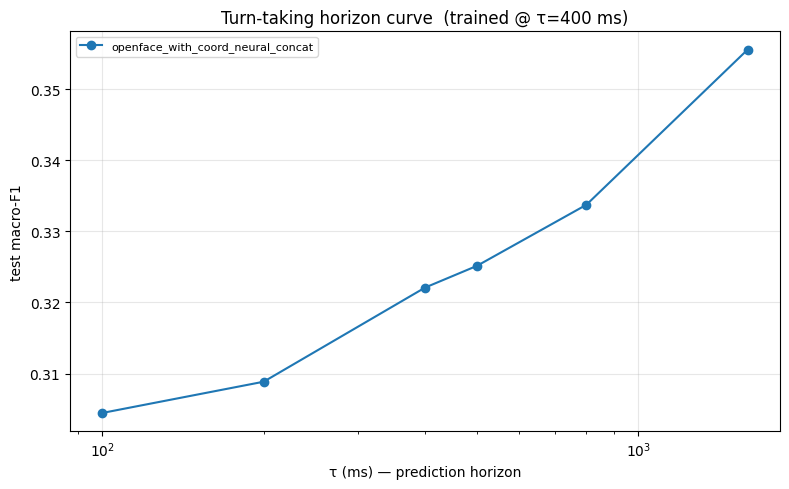

In [25]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for name, curve in tau_curves.items():
    taus = sorted(curve.keys())
    f1s = [curve[t]['macro_f1'] for t in taus]
    ax.plot(taus, f1s, marker='o', label=name)

ax.set_xlabel('τ (ms) — prediction horizon')
ax.set_ylabel('test macro-F1')
ax.set_title(f'Turn-taking horizon curve  (trained @ τ={TRAIN_TAU_MS} ms)')
ax.set_xscale('log')
ax.grid(True, alpha=0.3)
ax.legend(loc='best', fontsize=8)
plt.tight_layout()
plt.show()

## Section 7 — Save Results Data 
### (it is excessive, but we won't regret having too much to make figs from I think)

Write a JSON of results (minus `model_state`, which is a tensor dict) for later comparison across notebook runs.

In [ ]:
os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1" # get rid of debugger output

In [ ]:
## Section 7 — Persist detailed results for offline analysis & figure-making

# Why so much detail: the in-memory `results` and `tau_curves` dicts only carry
# scalar summaries (macro-F1, per-class F1). To make confusion-matrix heatmaps,
# ROC/AUC curves, calibration plots, per-interaction breakdowns, or any kind of
# error analysis later, we need the per-sample softmax probabilities, the
# predicted/true class per sample, sample identifiers, and full per-class
# precision/recall/F1/support — at every τ we evaluate.
#
# Output layout:
#   model_input/fusion_runs/<run_id>/run_index.json    — overall run metadata
#   model_input/fusion_runs/<run_id>/<exp_name>.json   — full per-experiment results

import json, os, sys, time
from collections import Counter, defaultdict
from datetime import datetime

import numpy as np
import torch

from pathlib import Path

RUN_ID = time.strftime('%Y%m%d_%H%M%S')
#OUT_DIR = PROJ / 'model_input' / 'fusion_runs' / RUN_ID

OUT_DIR = Path(f'/Users/kaitlinzareno/Desktop/csci535/csci535-project/results/coord_fusion/{RUN_ID}')
OUT_DIR.mkdir(parents=True, exist_ok=True)
DEVICE = fl.resolve_device('auto')

LABELS_DIR = '/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/labels_tau/'
LABELS_DIR = Path(LABELS_DIR)

OPENFACE_DIR = Path("/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/openface_new")

MODALITY_REGISTRY["openface"]["dir"] = str(OPENFACE_DIR)

print(MODALITY_REGISTRY["openface"])

# test_rel = Path("V00_S1295_I00000280_P0518/0000.00-0002.00_V00_S1295_I00000280_P0518.npy")
# test_full = Path(MODALITY_REGISTRY["openface"]["dir"]) / test_rel

# print(test_full)
# print(test_full.exists())

# ---------------------------------------------------------------------------
# Helpers — kept local to Section 7 so we don't have to touch fusion_lib.
# ---------------------------------------------------------------------------

def _inference_with_probs(model, loader, device):
    """Run inference, capture per-sample softmax probs + argmax preds + labels."""
    model.eval()
    probs_chunks, preds, labels = [], [], []
    with torch.inference_mode():
        for streams, ys in loader:
            streams = [t.to(device) for t in streams]
            logits = model(streams)
            p = torch.softmax(logits, dim=-1).cpu().numpy()
            probs_chunks.append(p)
            preds.extend(p.argmax(-1).tolist())
            labels.extend(ys.cpu().tolist())
    probs = np.concatenate(probs_chunks, axis=0) if probs_chunks else np.zeros((0, fl.NUM_CLASSES), dtype=np.float32)
    return probs, preds, labels


def _confusion_matrix(preds, labels, num_classes=fl.NUM_CLASSES):
    """Rows = true class, cols = predicted class. Counts."""
    cm = [[0] * num_classes for _ in range(num_classes)]
    for p, y in zip(preds, labels):
        if 0 <= y < num_classes and 0 <= p < num_classes:
            cm[y][p] += 1
    return cm


def _per_class_metrics(preds, labels, num_classes=fl.NUM_CLASSES):
    """precision, recall, F1, support, plus raw tp/fp/fn for downstream stats."""
    out = {}
    for c in range(num_classes):
        tp = sum(1 for p, y in zip(preds, labels) if p == c and y == c)
        fp = sum(1 for p, y in zip(preds, labels) if p == c and y != c)
        fn = sum(1 for p, y in zip(preds, labels) if p != c and y == c)
        support = sum(1 for y in labels if y == c)
        prec = tp / (tp + fp) if (tp + fp) else 0.0
        rec  = tp / (tp + fn) if (tp + fn) else 0.0
        f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
        out[fl.CLASS_NAMES[c]] = {
            'precision': prec, 'recall': rec, 'f1': f1,
            'support': support, 'tp': tp, 'fp': fp, 'fn': fn,
        }
    return out


def _aggregate_macro(per_class: dict) -> dict:
    """Macro precision/recall/F1 (unweighted mean over classes) + weighted F1
    (mean over classes weighted by support — useful when you want a single
    number that respects class imbalance)."""
    classes = list(per_class.values())
    n = len(classes) or 1
    macro_p  = sum(c['precision'] for c in classes) / n
    macro_r  = sum(c['recall']    for c in classes) / n
    macro_f1 = sum(c['f1']        for c in classes) / n
    total_support = sum(c['support'] for c in classes) or 1
    weighted_f1 = sum(c['f1'] * c['support'] for c in classes) / total_support
    return {
        'macro_precision': macro_p,
        'macro_recall':    macro_r,
        'macro_f1':        macro_f1,
        'weighted_f1':     weighted_f1,
    }


def _grouped_metrics(samples, preds, labels, key_fn):
    """Slice (samples, preds, labels) by `key_fn(sample)` and compute per-group
    n / macro-F1 / per-class metrics / confusion matrix. Used for per-interaction,
    per-participant, per-relationship breakdowns."""
    groups = defaultdict(lambda: {'preds': [], 'labels': []})
    for s, p, y in zip(samples, preds, labels):
        k = key_fn(s)
        groups[k]['preds'].append(p)
        groups[k]['labels'].append(y)
    out = {}
    for k, d in groups.items():
        per_class = _per_class_metrics(d['preds'], d['labels'])
        agg = _aggregate_macro(per_class)
        out[k] = {
            'n_samples': len(d['preds']),
            **agg,
            'per_class': per_class,
            'confusion_matrix': _confusion_matrix(d['preds'], d['labels']),
        }
    return out


# Manifest-derived lookup for relationship / participant slicing.
_iid_to_relationship = {r['interaction_id']: r.get('relationship', 'unknown')
                        for r in manifest_rows}
_iid_to_relationship_detail = {r['interaction_id']: r.get('relationship_detail', 'unknown')
                                for r in manifest_rows}


# ---------------------------------------------------------------------------
# Per-experiment full re-evaluation across τ-grid
# ---------------------------------------------------------------------------

detailed_results = {}

print("coordination_results keys:", list(coordination_results.keys()))

expected = set(EXPERIMENTS_COORDINATION.keys())
actual = set(coordination_results.keys())

print("expected:", expected)
print("actual:", actual)
print("missing:", expected - actual)


for exp_name in EXPERIMENTS_COORDINATION.keys():

    if exp_name not in coordination_results:
        print(f"SKIPPING {exp_name}: not found in coordination_results")
        continue

    exp_res = coordination_results[exp_name]

    if "model_state" not in exp_res:
        print(f"SKIPPING {exp_name}: no model_state")
        continue

    print(f"\nSaving detailed results for: {exp_name}")
    cfg          = exp_res['config']
    stream_cfg   = cfg['streams']
    fusion       = cfg['fusion']
    stream_dims  = exp_res['stream_dims']

    # Rebuild model + load best-val weights captured during run_experiment.
    model = fl.build_model(
        fusion, stream_dims,
        hidden_size      = cfg['hidden_size'],
        dropout          = cfg.get('dropout', 0.3),
        num_layers_early = cfg.get('num_layers_early', 3),
    ).to(DEVICE)
    model.load_state_dict(exp_res['model_state'])

    # Class weights actually used during training. Recomputed deterministically
    # from the same train split + label file → matches what optimization saw.
    train_labels_for_weights = fl.load_labels(cfg['labels_path'])
    train_samples_for_weights = [
        s for s in fl.enumerate_samples(manifest_rows, train_labels_for_weights)
        if s['split'] == 'train'
    ]
    class_weights_used = fl.compute_class_weights(train_samples_for_weights).cpu().tolist()

    # Best-epoch stamp. With patience-based early stopping the loop may have
    # exited well before `epochs`, so this is informative.
    history = exp_res['train_history']
    best_epoch_entry = max(history, key=lambda h: h['val_macro_f1']) if history else None

    n_params = sum(int(p.numel()) for p in model.parameters())

    tau_results = {}

    for tau_ms in fl.DEFAULT_TAU_GRID_MS:

        manifest_test_iids = set(r["interaction_id"] for r in manifest_rows if r["split"] == "test")
        sample_iids = set(s["interaction_id"] for s in samples)
        test_iids = set(s["interaction_id"] for s in test_samples)

        print(f"\nτ={tau_ms}")
        print("manifest test interactions:", len(manifest_test_iids))
        print("labeled sample interactions:", len(sample_iids))
        print("test sample interactions:", len(test_iids))
        print("missing from labels/samples:", sorted(manifest_test_iids - test_iids)[:20])

        labels_path = LABELS_DIR / f'labels_tau_{tau_ms:04d}.json'
        if not labels_path.exists():
            continue
        labels_dict = fl.load_labels(str(labels_path))
        samples = fl.enumerate_samples(manifest_rows, labels_dict)
        test_samples = [s for s in samples if s['split'] == 'test']
        if not test_samples:
            continue

        ####### make sure things are loading
        labels_dict = fl.load_labels(str(labels_path))
        samples = fl.enumerate_samples(manifest_rows, labels_dict)
        test_samples = [s for s in samples if s["split"] == "test"]

        print("manifest interactions:", len(set(r["interaction_id"] for r in manifest_rows)))
        print("all labeled sample interactions:", len(set(s["interaction_id"] for s in samples)))
        print("test sample interactions:", len(set(s["interaction_id"] for s in test_samples)))

        print("manifest test interactions:", len(set(
            r["interaction_id"] for r in manifest_rows if r["split"] == "test"
        )))

        missing_from_test_samples = (
            set(r["interaction_id"] for r in manifest_rows if r["split"] == "test")
            - set(s["interaction_id"] for s in test_samples)
        )

        print("missing test interactions:", sorted(missing_from_test_samples)[:20])
        print("n missing:", len(missing_from_test_samples))

        missing_iids = sorted(missing_from_test_samples)

        for iid in missing_iids[:10]:
            matching_labels = [
                k for k in labels_dict.keys()
                if iid in k
            ]
            print(iid, "n label entries:", len(matching_labels))

        coord_df = pd.read_csv(COORDINATION_CSV_PATH)

        print("coord interactions:", coord_df["interaction_name"].nunique())

        missing_coord = (
            set(s["interaction_id"] for s in test_samples)
            - set(coord_df["interaction_name"])
        )

        print("test interactions missing coordination:", len(missing_coord))
        print(sorted(missing_coord)[:20])

        ####### make sure things are loading

        loader = fl.make_dataloader_coordination(
            test_samples, stream_cfg, MODALITY_REGISTRY,
            batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS,
        )
        probs, preds, labels = _inference_with_probs(model, loader, DEVICE)
        per_class = _per_class_metrics(preds, labels)
        agg       = _aggregate_macro(per_class)

        # Test-loss using the SAME class-weighted criterion training optimized
        # against — comparable to training-time train_loss / val_loss numbers.
        criterion = torch.nn.CrossEntropyLoss(
            weight=torch.tensor(class_weights_used, dtype=torch.float32, device=DEVICE)
        )
        with torch.inference_mode():
            test_loss = 0.0
            n = 0
            for streams, ys in loader:
                streams = [t.to(DEVICE) for t in streams]
                ys = ys.to(DEVICE)
                logits = model(streams)
                test_loss += criterion(logits, ys).item() * ys.size(0)
                n += ys.size(0)
            test_loss = test_loss / max(n, 1)

        # Per-sample records — minimal but enough for downstream slicing.
        # `probs` is converted to a list of 3-floats so JSON can hold it.
        sample_records = [
            {
                'basename':         s['basename'],
                'interaction_id':   s['interaction_id'],
                'speaker_file_id':  s['speaker_file_id'],
                'listener_file_id': s['listener_file_id'],
                'window_start_s':   s['start_s'],
                'window_end_s':     s['end_s'],
                'split':            s['split'],
                'label':            int(y),
                'pred':             int(p),
                'probs':            [float(x) for x in row],
                'correct':          int(p) == int(y),
            }
            for s, p, y, row in zip(test_samples, preds, labels, probs)
        ]

        tau_results[str(tau_ms)] = {
            'n_test_samples':    len(test_samples),
            'test_loss':         test_loss,
            **agg,                                     # macro_precision/recall/f1, weighted_f1
            'per_class':         per_class,            # precision/recall/F1/support per class
            'confusion_matrix':  _confusion_matrix(preds, labels),
            'class_distribution_test': dict(Counter(labels)),
            'per_interaction':   _grouped_metrics(
                                    test_samples, preds, labels,
                                    key_fn=lambda s: s['interaction_id']),
            'per_speaker':       _grouped_metrics(
                                    test_samples, preds, labels,
                                    key_fn=lambda s: s['speaker_file_id']),
            'per_relationship':  _grouped_metrics(
                                    test_samples, preds, labels,
                                    key_fn=lambda s: _iid_to_relationship.get(
                                        s['interaction_id'], 'unknown')),
            'per_relationship_detail': _grouped_metrics(
                                    test_samples, preds, labels,
                                    key_fn=lambda s: _iid_to_relationship_detail.get(
                                        s['interaction_id'], 'unknown')),
            'sample_records':    sample_records,
        }

    detailed_results[exp_name] = {
        'experiment_name':    exp_name,
        'config':             cfg,
        'stream_dims':        stream_dims,
        'device':             exp_res['device'],
        'n_params':           n_params,
        'class_weights_used': class_weights_used,
        'samples_summary':    exp_res['samples_summary'],
        'train_history':      history,
        'best_epoch':         best_epoch_entry['epoch']        if best_epoch_entry else None,
        'best_val_macro_f1':  best_epoch_entry['val_macro_f1'] if best_epoch_entry else None,
        'epochs_completed':   len(history),
        'tau_results':        tau_results,
    }

    # Persist per-experiment file.
    out_path = OUT_DIR / f'{exp_name}.json'
    with open(out_path, 'w') as f:
        json.dump(detailed_results[exp_name], f, indent=2, default=str)

    print(f'  wrote {out_path}')
    print(f'  size: {out_path.stat().st_size / 1024:.1f} KB')

# ---------------------------------------------------------------------------
# Run-level index — captures everything needed to reproduce or compare runs.
# ---------------------------------------------------------------------------

run_index = {
    'run_id':              RUN_ID,
    'timestamp':           datetime.now().isoformat(),
    'manifest_path':       str(MANIFEST_PATH),
    'train_labels_path':   str(TRAIN_LABELS_PATH),
    'train_tau_ms':        TRAIN_TAU_MS,
    'tau_grid_ms':         list(fl.DEFAULT_TAU_GRID_MS),
    'modality_registry':   MODALITY_REGISTRY,
    'global_hyperparams': {
        'hidden_size':       HIDDEN_SIZE,
        'dropout':           DROPOUT,
        'num_layers_early':  NUM_LAYERS_EARLY,
        'epochs':            EPOCHS,
        'batch_size':        BATCH_SIZE,
        'learning_rate':     LEARNING_RATE,
        'patience':          PATIENCE,
        'num_workers':       NUM_WORKERS,
        'seed':              SEED,
        'max_samples_per_split': MAX_SAMPLES_PER_SPLIT,
    },
    'experiments':         list(detailed_results.keys()),
    'experiment_summary': {  # quick scan-line per experiment, training-τ test
        name: {
            'fusion':       d['config']['fusion'],
            'streams':      d['config']['streams'],
            'n_params':     d['n_params'],
            'best_epoch':   d['best_epoch'],
            'epochs_run':   d['epochs_completed'],
            'test_macro_f1_at_train_tau': d['tau_results']
                                              .get(str(TRAIN_TAU_MS), {})
                                              .get('macro_f1'),
            "tau_summary": {
                                tau: {
                                    "n_samples": tr.get("n_test_samples"),
                                    "n_interactions": len(tr.get("per_interaction", {})),
                                }
                                for tau, tr in d["tau_results"].items()
                            },
        }
        for name, d in detailed_results.items()
    },
    'environment': {
        'torch_version':  torch.__version__,
        'python_version': sys.version.split()[0],
        'device':         str(DEVICE),
        'platform':       sys.platform,
    },
}

with open(OUT_DIR / 'run_index.json', 'w') as f:
    json.dump(run_index, f, indent=2, default=str)
print(f'  wrote {OUT_DIR / "run_index.json"}')

print(f'\nRun directory: {OUT_DIR}')
print(f'Files:')
for p in sorted(OUT_DIR.iterdir()):
    print(f'  {p.name}  ({p.stat().st_size / 1024:.1f} KB)')

{'kind': 'spliced', 'dir': '/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/openface_new', 'feature_dim': 23, 'frame_rate_hz': 30.0, 'folder': '/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/openface_new'}
/Users/kaitlinzareno/Desktop/csci535/csci535-project/data/openface_new/V00_S1295_I00000280_P0518/0000.00-0002.00_V00_S1295_I00000280_P0518.npy
True
coordination_results keys: ['openface_with_coord_neural_concat']
expected: {'openface_with_coord_neural_concat'}
actual: {'openface_with_coord_neural_concat'}
missing: set()

Saving detailed results for: openface_with_coord_neural_concat

τ=100
manifest test interactions: 34
labeled sample interactions: 222
test sample interactions: 34
missing from labels/samples: []
manifest interactions: 222
all labeled sample interactions: 222
test sample interactions: 34
manifest test interactions: 34
missing test interactions: []
n missing: 0
coord interactions: 457
test interactions missing coordination: 0
[]

τ=200
manifest tes